<a href="https://colab.research.google.com/github/divya910agarwal/nifty50-volatility-modeling/blob/main/volatility_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

data = pd.read_csv('/content/drive/My Drive/cND30Y.csv')

# Clean price column and parse dates
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')
data = data.sort_values('Date').reset_index(drop=True)

# Recompute log returns from scratch
data['Log_Returns'] = np.log(data['Price'] / data['Price'].shift(1))
data = data.dropna(subset=['Log_Returns']).reset_index(drop=True)

print(f"Data shape: {data.shape}")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print(data[['Date','Price','Log_Returns']].head())

Data shape: (7151, 8)
Date range: 1995-11-07 00:00:00 to 2024-08-05 00:00:00
        Date   Price  Log_Returns
0 1995-11-07  978.22    -0.010879
1 1995-11-08  964.01    -0.014633
2 1995-11-09  953.07    -0.011413
3 1995-11-10  948.82    -0.004469
4 1995-11-13  917.26    -0.033828


DESCRIPTIVE STATISTICS - NIFTY50 LOG RETURNS
Observations : 7151
Mean         : 0.000446
Median       : 0.000845
Std Dev      : 0.014479
Maximum      : 0.163343
Minimum      : -0.139038
Skewness     : -0.328703
Kurtosis     : 12.118750
Jarque-Bera  : 24904.4872
JB p-value   : 0.000000


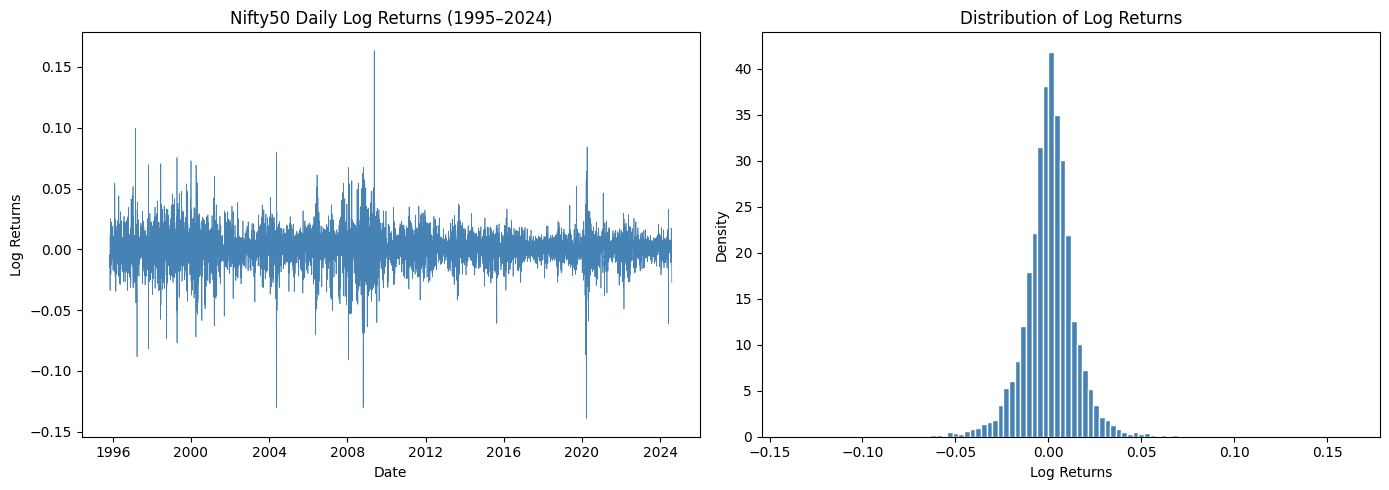

In [5]:

from scipy.stats import kurtosis, skew, jarque_bera

returns = data['Log_Returns']

print("=" * 50)
print("DESCRIPTIVE STATISTICS - NIFTY50 LOG RETURNS")
print("=" * 50)
print(f"Observations : {len(returns)}")
print(f"Mean         : {returns.mean():.6f}")
print(f"Median       : {returns.median():.6f}")
print(f"Std Dev      : {returns.std():.6f}")
print(f"Maximum      : {returns.max():.6f}")
print(f"Minimum      : {returns.min():.6f}")
print(f"Skewness     : {skew(returns):.6f}")
print(f"Kurtosis     : {kurtosis(returns, fisher=False):.6f}")  # excess=False gives actual kurtosis, normal=3

jb_stat, jb_pval = jarque_bera(returns)
print(f"Jarque-Bera  : {jb_stat:.4f}")
print(f"JB p-value   : {jb_pval:.6f}")
print("=" * 50)

# Plot returns distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(data['Date'], returns, color='steelblue', linewidth=0.5)
axes[0].set_title('Nifty50 Daily Log Returns (1995–2024)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Returns')

axes[1].hist(returns, bins=100, color='steelblue', edgecolor='white', density=True)
axes[1].set_title('Distribution of Log Returns')
axes[1].set_xlabel('Log Returns')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [6]:

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(returns, autolag='AIC')

print("=" * 50)
print("AUGMENTED DICKEY-FULLER TEST")
print("=" * 50)
print(f"ADF Statistic : {adf_result[0]:.6f}")
print(f"p-value       : {adf_result[1]:.6f}")
print(f"Critical Values:")
for key, val in adf_result[4].items():
    print(f"   {key}: {val:.4f}")
print("=" * 50)
if adf_result[1] < 0.05:
    print("RESULT: Reject unit root → Series is STATIONARY ✓")
else:
    print("RESULT: Cannot reject unit root → Series is NON-STATIONARY")

AUGMENTED DICKEY-FULLER TEST
ADF Statistic : -19.137484
p-value       : 0.000000
Critical Values:
   1%: -3.4313
   5%: -2.8619
   10%: -2.5670
RESULT: Reject unit root → Series is STATIONARY ✓


# ARCH-LM Test


In [7]:

from statsmodels.stats.diagnostic import het_arch

lm_stat, lm_pval, f_stat, f_pval = het_arch(returns, nlags=5)

print("=" * 50)
print("ARCH-LM TEST (lag=5)")
print("=" * 50)
print(f"LM Statistic  : {lm_stat:.4f}")
print(f"LM p-value    : {lm_pval:.6f}")
print(f"F Statistic   : {f_stat:.4f}")
print(f"F p-value     : {f_pval:.6f}")
print("=" * 50)
if lm_pval < 0.05:
    print("RESULT: Reject no-ARCH null → ARCH effects present ✓")
    print("GARCH modeling is justified.")
else:
    print("RESULT: No ARCH effects detected")

ARCH-LM TEST (lag=5)
LM Statistic  : 648.3560
LM p-value    : 0.000000
F Statistic   : 142.4905
F p-value     : 0.000000
RESULT: Reject no-ARCH null → ARCH effects present ✓
GARCH modeling is justified.


# Model Fitting - GARCH, EGARCH, GJR-GARCH, APARCH


In [8]:
!pip install arch
from arch import arch_model

scaled_returns = returns * 100  # scaling is standard practice, improves optimizer convergence

models = {
    'GARCH(1,1)'    : arch_model(scaled_returns, vol='Garch', p=1, q=1),
    'EGARCH(1,1)'   : arch_model(scaled_returns, vol='EGarch', p=1, q=1),
    'GJR-GARCH(1,1)': arch_model(scaled_returns, vol='Garch', p=1, o=1, q=1),
    'APARCH(1,1)'   : arch_model(scaled_returns, vol='APARCH', p=1, q=1),
}

results = {}
for name, model in models.items():
    fit = model.fit(disp='off')
    results[name] = fit
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Log-Likelihood : {fit.loglikelihood:.4f}")
    print(f"  AIC            : {fit.aic:.4f}")
    print(f"  BIC            : {fit.bic:.4f}")

# Summary comparison table
print(f"\n{'='*50}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*50}")
print(f"{'Model':<20} {'LogL':>10} {'AIC':>10} {'BIC':>10}")
print("-"*50)
for name, fit in results.items():
    print(f"{name:<20} {fit.loglikelihood:>10.4f} {fit.aic:>10.4f} {fit.bic:>10.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.8 MB/s eta 0:00:00

  GARCH(1,1)
  Log-Likelihood : -11537.5165
  AIC            : 23083.0331
  BIC            : 23110.5331

  EGARCH(1,1)
  Log-Likelihood : -11548.8966
  AIC            : 23105.7932
  BIC            : 23133.2933

  GJR-GARCH(1,1)
  Log-Likelihood : -11498.9741
  AIC            : 23007.9482
  BIC            : 23042.3232

  APARCH(1,1)
  Log-Likelihood : -11536.5151
  AIC            : 23083.0302
  BIC            : 23117.4052

MODEL COMPARISON SUMMARY
Model                      LogL        AIC        BIC
--------------------------------------------------
GARCH(1,1)           -11537.5165 23083.0331 23110.5331
EGARCH(1,1)          -11548.8966 23105.7932 23133.2933
GJR-GARCH(1,1)       -11498.9741 23007.9482 23042.3232
APARCH(1,1)          -11536.5151 23083.0302 23117.4052


# GJR-GARCH full summary


In [9]:
print(results['GJR-GARCH(1,1)'].summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -11499.0
Distribution:                  Normal   AIC:                           23007.9
Method:            Maximum Likelihood   BIC:                           23042.3
                                        No. Observations:                 7151
Date:                Tue, Mar 10 2026   Df Residuals:                     7150
Time:                        13:47:22   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0590  1.272e-02      4.639  3.499e-06 [3.

In [10]:
print(results['EGARCH(1,1)'].summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -11548.9
Distribution:                  Normal   AIC:                           23105.8
Method:            Maximum Likelihood   BIC:                           23133.3
                                        No. Observations:                 7151
Date:                Tue, Mar 10 2026   Df Residuals:                     7150
Time:                        13:47:22   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0900  1.335e-02      6.737  1.614e-11 [6.380e-0

# Train/Test Split - 90/10

In [11]:

split = int(len(scaled_returns) * 0.90)
train = scaled_returns.iloc[:split]
test  = scaled_returns.iloc[split:]

print(f"Train: {len(train)} observations ({data['Date'].iloc[0].date()} to {data['Date'].iloc[split-1].date()})")
print(f"Test : {len(test)} observations ({data['Date'].iloc[split].date()} to {data['Date'].iloc[-1].date()})")

Train: 6435 observations (1995-11-07 to 2021-09-15)
Test : 716 observations (2021-09-16 to 2024-08-05)


# Rolling 1-step ahead forecast for all four models

In [12]:


model_specs = {
    'GARCH(1,1)'    : {'vol': 'Garch',  'p': 1, 'o': 0, 'q': 1},
    'EGARCH(1,1)'   : {'vol': 'EGarch', 'p': 1, 'o': 1, 'q': 1},
    'GJR-GARCH(1,1)': {'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1},
    'APARCH(1,1)'   : {'vol': 'APARCH', 'p': 1, 'o': 1, 'q': 1},
}

forecasts = {name: [] for name in model_specs}

for i in range(len(test)):
    window = scaled_returns.iloc[:split + i]
    for name, spec in model_specs.items():
        m = arch_model(window, mean='Constant', **spec)
        fit = m.fit(disp='off')
        fcast = fit.forecast(horizon=1)
        forecasts[name].append(fcast.variance.values[-1, 0])
    if i % 100 == 0:
        print(f"Step {i}/{len(test)} complete...")

print("Forecasting complete.")

Step 0/716 complete...
Step 100/716 complete...
Step 200/716 complete...
Step 300/716 complete...
Step 400/716 complete...
Step 500/716 complete...
Step 600/716 complete...
Step 700/716 complete...
Forecasting complete.


# Forecast Evaluation

In [13]:


# Realized variance = squared actual returns on test period
realized_variance = test.values ** 2

# Build results dataframe
eval_results = {}
for name, fcast in forecasts.items():
    fcast_array = np.array(fcast)
    mse = np.mean((realized_variance - fcast_array) ** 2)
    mae = np.mean(np.abs(realized_variance - fcast_array))
    # R² between forecast and realized
    ss_res = np.sum((realized_variance - fcast_array) ** 2)
    ss_tot = np.sum((realized_variance - np.mean(realized_variance)) ** 2)
    r2 = 1 - ss_res / ss_tot
    eval_results[name] = {'MSE': mse, 'MAE': mae, 'R²': r2}

eval_df = pd.DataFrame(eval_results).T
eval_df = eval_df.sort_values('MSE')

print("=" * 55)
print("OUT-OF-SAMPLE FORECAST EVALUATION")
print("=" * 55)
print(f"{'Model':<20} {'MSE':>10} {'MAE':>10} {'R²':>8}")
print("-" * 55)
for name, row in eval_df.iterrows():
    print(f"{name:<20} {row['MSE']:>10.4f} {row['MAE']:>10.4f} {row['R²']:>8.4f}")
print("=" * 55)
print(f"\nBest model by MSE: {eval_df['MSE'].idxmin()}")
print(f"Best model by MAE: {eval_df['MAE'].idxmin()}")

OUT-OF-SAMPLE FORECAST EVALUATION
Model                       MSE        MAE       R²
-------------------------------------------------------
APARCH(1,1)              4.3430     0.9416   0.0231
EGARCH(1,1)              4.3474     0.9440   0.0221
GARCH(1,1)               4.3673     0.9443   0.0176
GJR-GARCH(1,1)           4.4341     0.9566   0.0026

Best model by MSE: APARCH(1,1)
Best model by MAE: APARCH(1,1)


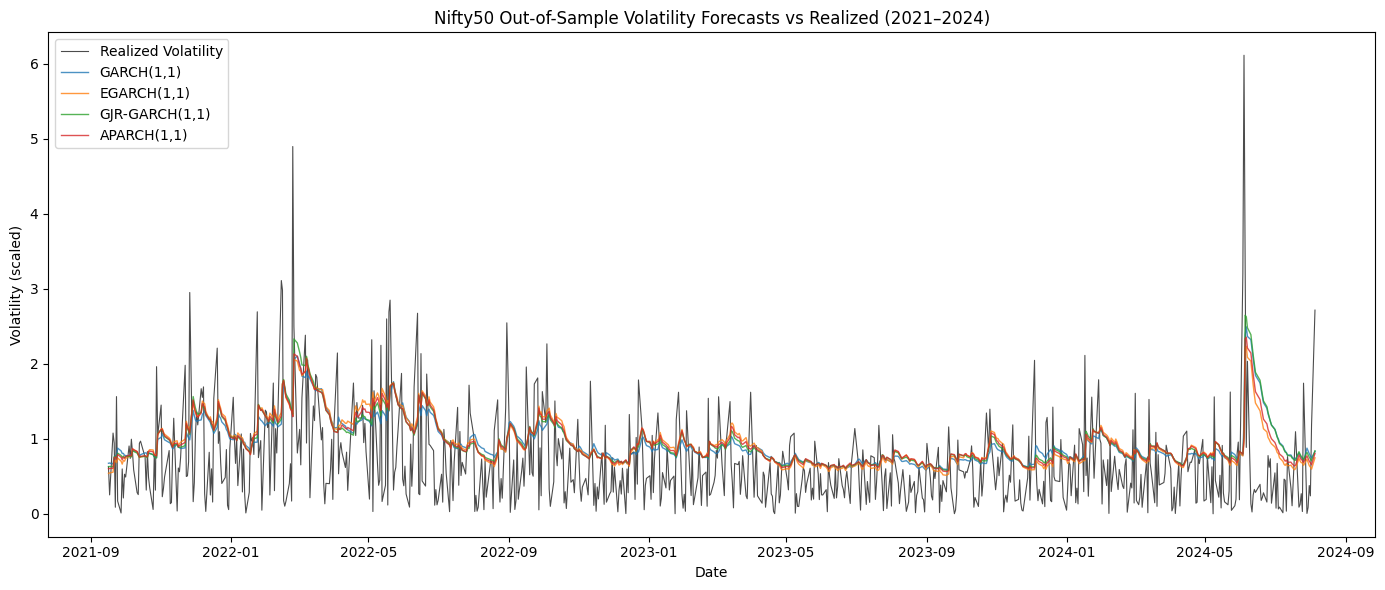

In [14]:
# Plot forecasted vs realized volatility
realized_vol = np.sqrt(realized_variance)
dates_test = data['Date'].iloc[split:split+len(test)].values

plt.figure(figsize=(14, 6))
plt.plot(dates_test, realized_vol, color='black', linewidth=0.8, label='Realized Volatility', alpha=0.7)
for name, fcast in forecasts.items():
    plt.plot(dates_test, np.sqrt(fcast), linewidth=1, label=name, alpha=0.8)

plt.title('Nifty50 Out-of-Sample Volatility Forecasts vs Realized (2021–2024)')
plt.xlabel('Date')
plt.ylabel('Volatility (scaled)')
plt.legend()
plt.tight_layout()
plt.show()

# EXPERIMENTS SECTION


# Experiment 1: Better Realized Variance (21-day rolling)

In [ ]:

realized_var_rolling = returns.iloc[split:split+len(test)].rolling(21).var() * 100**2
realized_var_rolling = realized_var_rolling.dropna().values

# Trim forecasts to match
trim = len(test) - len(realized_var_rolling)

print("R² with rolling realized variance:")
for name, fcast in forecasts.items():
    fcast_trimmed = np.array(fcast[trim:])
    ss_res = np.sum((realized_var_rolling - fcast_trimmed) ** 2)
    ss_tot = np.sum((realized_var_rolling - np.mean(realized_var_rolling)) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f"  {name:<20}: R² = {r2:.4f}")

R² with rolling realized variance:
  GARCH(1,1)          : R² = 0.7208
  EGARCH(1,1)         : R² = 0.5717
  GJR-GARCH(1,1)      : R² = 0.5805
  APARCH(1,1)         : R² = 0.6121


# Experiment 2: Student-t error distribution

In [17]:

model_specs_t = {
    'GARCH(1,1)-t'    : {'vol': 'Garch',  'p': 1, 'o': 0, 'q': 1},
    'EGARCH(1,1)-t'   : {'vol': 'EGarch', 'p': 1, 'o': 1, 'q': 1},
    'GJR-GARCH(1,1)-t': {'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1},
    'APARCH(1,1)-t'   : {'vol': 'APARCH', 'p': 1, 'o': 1, 'q': 1},
}

forecasts_t = {name: [] for name in model_specs_t}

for i in range(len(test)):
    window = scaled_returns.iloc[:split + i]
    for name, spec in model_specs_t.items():
        m = arch_model(window, mean='Constant', dist='t', **spec)
        fit = m.fit(disp='off')
        fcast = fit.forecast(horizon=1)
        forecasts_t[name].append(fcast.variance.values[-1, 0])
    if i % 100 == 0:
        print(f"Step {i}/{len(test)} complete...")

print("Done.")

Step 0/716 complete...
Step 100/716 complete...
Step 200/716 complete...
Step 300/716 complete...
Step 400/716 complete...
Step 500/716 complete...
Step 600/716 complete...
Step 700/716 complete...
Done.


In [19]:
realized_variance = test.values ** 2

# Re-define realized_var_rolling and trim for this experiment
realized_var_rolling = returns.iloc[split:split+len(test)].rolling(21).var() * 100**2
realized_var_rolling = realized_var_rolling.dropna().values
trim = len(test) - len(realized_var_rolling)

eval_results_t = {}
for name, fcast in forecasts_t.items():
    fcast_array = np.array(fcast)

    # MSE and MAE against squared returns (standard)
    mse = np.mean((realized_variance - fcast_array) ** 2)
    mae = np.mean(np.abs(realized_variance - fcast_array))

    # R² against rolling realized variance (experiment)
    fcast_trimmed = fcast_array[trim:]
    ss_res = np.sum((realized_var_rolling - fcast_trimmed) ** 2)
    ss_tot = np.sum((realized_var_rolling - np.mean(realized_var_rolling)) ** 2)
    r2 = 1 - ss_res / ss_tot

    eval_results_t[name] = {'MSE': mse, 'MAE': mae, 'R²': r2}

eval_df_t = pd.DataFrame(eval_results_t).T.sort_values('MSE')

print("=" * 55)
print("OUT-OF-SAMPLE EVALUATION (Student-t distribution)")
print("=" * 55)
print(f"{'Model':<20} {'MSE':>10} {'MAE':>10} {'R²':>8}")
print("-" * 55)
for name, row in eval_df_t.iterrows():
    print(f"{name:<20} {row['MSE']:>10.4f} {row['MAE']:>10.4f} {row['R²']:>8.4f}")

OUT-OF-SAMPLE EVALUATION (Student-t distribution)
Model                       MSE        MAE       R²
-------------------------------------------------------
APARCH(1,1)-t            4.3147     0.9379   0.5862
EGARCH(1,1)-t            4.3371     0.9440   0.5638
GARCH(1,1)-t             4.3446     0.9399   0.7654
GJR-GARCH(1,1)-t         4.4209     0.9587   0.5971
